Phase 1: Document Preprocessing and Visualization

* **Objective** : Load PDFs/images, apply grayscale, denoising, CLAHE, and thresholding. Visualize the outputs side-by-side to record observations.

### Python - Setup and Imports

In [1]:
import sys
import os
import cv2
import matplotlib.pyplot as plt

# Add the src directory to the Python path so we can import our modules
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.preprocessing.pipeline import render_pdf_page, preprocess_document
print("Modules imported successfully!")

Modules imported successfully!


### Load the Document

In [2]:
# Define the path to one of your sample PDFs in the data/raw folder
# Change 'sample.pdf' to the actual name of your file!
pdf_path = "E:\\document-ai\\data\\raw\\Bayesian_Reflection.pdf"

# Render the first page at 300 DPI
original_img = render_pdf_page(pdf_path, page_num=0, dpi=300)

# Run the preprocessing pipeline we wrote earlier
stages = preprocess_document(original_img)
print("Preprocessing complete. Stages available: ", list(stages.keys()))

Preprocessing complete. Stages available:  ['original', 'grayscale', 'denoised', 'clahe', 'thresholded']


### Visualize the Pipeline

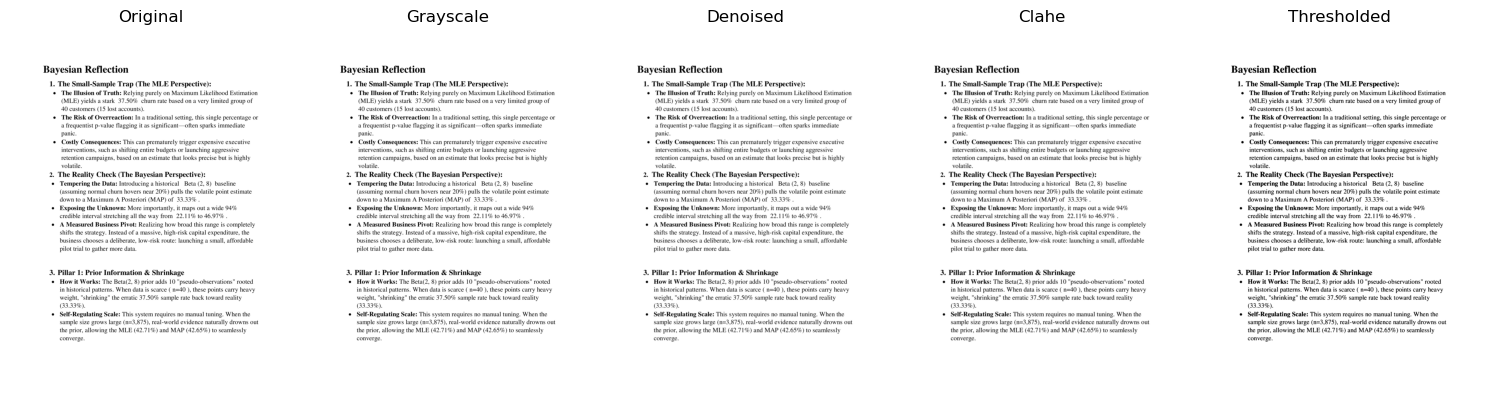

In [3]:
def plot_stages(stages_dict):
    """Plots the original image and all preprocessing stages side-by-side."""
    n_stages = len(stages_dict)
    plt.figure(figsize=(15, 5 * n_stages))
    
    for i, (stage_name, img) in enumerate(stages_dict.items()):
        plt.subplot(1, n_stages, i + 1)
        
        # If the image is grayscale, use gray colormap
        if len(img.shape) == 2:
            plt.imshow(img, cmap='gray')
        else:
            # Convert BGR to RGB for matplotlib
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            
        plt.title(stage_name.capitalize(), fontsize=12)
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

# Display the results
plot_stages(stages)

### Observations

1. Grayscale Conversion

**Observation**: Color information is completely removed, but all text and structural layout remain perfectly intact.
**Impact**: Successfully reduces the image from 3 channels (RGB) to 1 channel, reducing computational overhead for downstream tasks while preserving all necessary text features.

2. Gaussian Denoising

**Observation**: On a native digital PDF (like this arXiv paper), the visual change is minimal. The text edges appear very slightly softened.
**Impact**: Because there is no scanner noise or paper texture in native PDFs, the filter has little to correct. However, this step is crucial as a safety net for scanned or photographed documents, where it will smooth out background dust and grain.
3. CLAHE (Contrast Enhancement)

**Observation**: Local contrast is significantly enhanced. The distinction between the text and the background is maximized, making the text appear bolder and clearer against the background.
**Impact**: Highly effective for documents with uneven lighting or low-contrast scans. It ensures that faint text becomes readable, preventing OCR engines from dropping characters.
4. Otsu Thresholding

**Observation**: The image is perfectly binarized into pure black text and a pure white background. Otsu's algorithm automatically found the ideal pixel intensity threshold to separate foreground from background.
**Impact**: This is the optimal input format for OCR engines (like Tesseract). Binarization removes anti-aliasing (gray pixels on text edges), allowing the OCR engine to detect character contours with high precision and extract bounding boxes cleanly.

**Summary Conclusion**:
For high-quality native digital PDFs, grayscale and thresholding provide the most immediate benefit for OCR. However, the full pipeline (Denoising + CLAHE) is essential for ensuring robustness when the system later encounters degraded, scanned, or photographed documents.